In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pyntcloud
!pip install open3d
!pip install geomdl

In [ ]:
from pyntcloud import PyntCloud 
import numpy as np
from mpl_toolkits.mplot3d import Axes3D 
import matplotlib.pyplot as plt 
import pandas as pd
import os
import sys
import pdb
import open3d as o3d
import geomdl
from geomdl import fitting
from geomdl import BSpline
from geomdl import knotvector

**This is a function that can be used anywhere in the process to convert a PCD to Numpy array or Vice-Versa.**

In [ ]:
#Numpy to PCD and vice versa
def NumpyToPCD(xyz):
    """ convert numpy ndarray to open3D point cloud 
    Args:
        xyz (ndarray): 
    Returns:
        [open3d.geometry.PointCloud]: 
    """

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)

    return pcd


def PCDToNumpy(pcd):
    """  convert open3D point cloud to numpy ndarray
    Args:
        pcd (open3d.geometry.PointCloud): 
    Returns:
        [ndarray]: 
    """

    return np.asarray(pcd.points)

**Loading the extracted point cloud of weld-path**

In [ ]:
with open('/content/drive/MyDrive/Mitacs/seam-horizontal.npy', 'rb') as f:
  hz_points_unsorted = np.load(f)

In [ ]:
hz_points_sorted = hz_points_unsorted[hz_points_unsorted[:, 0].argsort()]
hz_points_arr = np.array(hz_points_sorted)
print("Shape of hz_array : ", hz_points_arr.shape)

Shape of hz_array :  (1237, 3)


**Visualizing the Array**

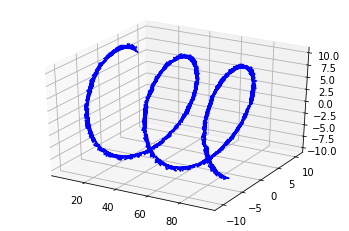

In [ ]:
evalpts2 = hz_points_arr

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot3D(evalpts2[:, 0], evalpts2[:, 1], evalpts2[:, 2], 'blue')

plt.show()

**Orienting it according to how it should get rendered in Gazebo**

In [ ]:
hz_points_arr[:, [1,0]] = hz_points_arr[:, [0,1]]

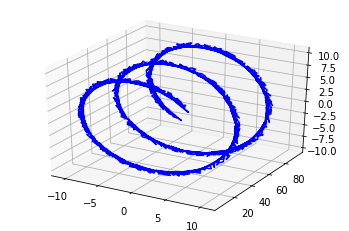

In [ ]:
evalpts2 = hz_points_arr

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot3D(evalpts2[:, 0], evalpts2[:, 1], evalpts2[:, 2], 'blue')

plt.show()

**Using B-Spline Code (This is used to make the weld path smoother, can be experimented with the real one as required)**

In [ ]:
hz_arr = hz_points_arr

knot3 = knotvector.generate(4, hz_arr.shape[0])

curve3 = BSpline.Curve()

# Set degree
curve3.degree = 4

# Set control points
#curve.ctrlpts = [[10, 5, 10], [10, 20, -30], [40, 10, 25], [-10, 5, 0]]
curve3.ctrlpts = hz_arr.tolist()
# Set knot vector
#curve.knotvector = [0, 0, 0, 0, 1, 1, 1, 1]
curve3.knotvector = knot3

# Set evaluation delta (controls the number of curve points)
curve3.delta = 0.00005

# Get curve points (the curve will be automatically evaluated)
curve3_points = curve3.evalpts

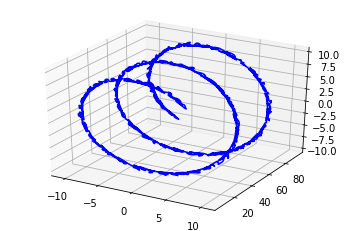

In [ ]:
evalptsL = np.array(curve3_points)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot3D(evalptsL[:, 0], evalptsL[:, 1], evalptsL[:, 2], 'blue')

plt.show()

**Reducing Points for Demonstration Purposes**

In [ ]:
#red_arr is Reduced Array
red_arr = []

for i in range(len(hz_points_arr)):
    if i%15==0:
        red_arr.append(hz_points_arr[i])

red_arr = np.array(red_arr)

**This can be used equally instead of the above**

In [ ]:
#Reducing Points for Bspline
red_bspline = []

for i in range(len(evalptsL)):
    if i%150==0:
        red_bspline.append(evalptsL[i])

red_bspline = np.array(red_bspline)

**Following this, I have demostrated using red_arr, anything similar like red_arr_bspline can be used.** 

*While calculation of angle, the library assumes that points are centered at origin - Manipulation of points such that auger is centered at Origin(0,0,0) is required, when it is not so, while calculation of angles. Here the points are already centered in (0,0,0). Visualisation shows it.*

***Re-calculating points to make the radius same [To make sure the arm doesn't go to points for welding inside the radius]. (A little manipulation for real purposes can be done as needed). Credits: Abhijay's CODE***

In [ ]:
trajpoints = red_arr

r = max(trajpoints[:, 0])

trajpoints_gap = np.zeros([len(trajpoints), 3])
for i in range(len(trajpoints)):
    if trajpoints[i][0] < 0:
        trajpoints_gap[i][0] = trajpoints[i][0] - 0.707
    else:
        trajpoints_gap[i][0] = trajpoints[i][0] + 0.707
    if trajpoints[i][2] < 0:
        trajpoints_gap[i][2] = trajpoints[i][2] - 0.707
    else:
        trajpoints_gap[i][2] = trajpoints[i][2] + 0.707
    trajpoints_gap[i][1] = trajpoints[i][1]

for i in range(len(trajpoints_gap)):
    x = r*trajpoints_gap[i][0]/(trajpoints_gap[i][0]**2+trajpoints_gap[i][2]**2)**0.5
    z = r*trajpoints_gap[i][2]/(trajpoints_gap[i][0]**2+trajpoints_gap[i][2]**2)**0.5
    trajpoints_gap[i][0] = x
    trajpoints_gap[i][2] = z


In [ ]:
red_arr = trajpoints_gap

In [ ]:
red_arr = red_arr/100

In [ ]:
red_arr

array([[ 0.06003643,  0.05058137,  0.08500082],
       [ 0.05685908,  0.06066791,  0.08715823],
       [ 0.02696619,  0.07163675,  0.10051038],
       [ 0.00785946,  0.08127242,  0.10376773],
       [ 0.01028447,  0.08964231,  0.1035555 ],
       [-0.03158842,  0.10482185,  0.09915485],
       [-0.04706666,  0.11569402,  0.09281294],
       [-0.06567949,  0.12815648,  0.08071999],
       [-0.07909228,  0.14180874,  0.06763078],
       [-0.09370163,  0.15146381,  0.0452716 ],
       [-0.09756023,  0.16184649,  0.03621483],
       [-0.10228153,  0.17276476,  0.01918336],
       [-0.10380109,  0.18367607,  0.0074058 ],
       [-0.10327602,  0.19362202, -0.01278964],
       [-0.08750362,  0.20511232, -0.05632609],
       [-0.08763134,  0.21790131, -0.05612718],
       [-0.06788666,  0.22874655, -0.07887277],
       [-0.05499066,  0.23950718, -0.08834896],
       [-0.04390881,  0.25088507, -0.09434791],
       [-0.03949789,  0.26349977, -0.09627787],
       [-0.00671279,  0.27409977, -0.103

In [ ]:
#Saving Point cloud
red_pcd = NumpyToPCD(red_arr)
o3d.io.write_point_cloud("red.pcd", red_pcd)

True

In [ ]:
#Final angle generation code
import copy
angles = []

red_pcd = o3d.io.read_point_cloud("/content/red.pcd") #red_pcd is used in the form of pointcloud as it is the rotation matrix and open3D requires it to be like that.

for i in range(83):
  red_arr1 = PCDToNumpy(red_pcd)
  angle = np.arctan2(red_arr1[i][0], red_arr1[i][2])
  angles.append(angle)
  print(angle)

  red_pcd_rotmat = copy.deepcopy(red_pcd)
  R = red_pcd_rotmat.get_rotation_matrix_from_axis_angle(np.array([0, -angle, 0]))

  red_pcd.rotate(R)

**Re-Orienting the points to fit the environment, after angle calculation using the above code, manipulate the position of auger as required, as now we have the angles required**

In [ ]:
#Re-Positioning the points (This can be manipulated as required according to the position need)
for i in range(83):
  red_arr[i][0]+=0.55
  red_arr[i][2]+=0.55
  red_arr[i][1]-=0.35

In [ ]:
#save point cloud for simulation and export it to ROS Environment
red_pcd = NumpyToPCD(red_arr)
o3d.io.write_point_cloud("red2.pcd", red_pcd)

True

In [ ]:
#save angles to run it in ROS
np.save('Correct_angles.npy', angles)

**Calculating the distance between points (i.e) "Z" in a general sense, that the arm would traverse while welding**


In [ ]:
#Calculate "Z" for robot. This can be used while real purpose, for simulation purpose I've done it a different way (Going from one point to another)
Z = np.zeros((red_arr.shape[0])); 
Z[0] = red_arr[0][1]
for i in range(1, red_arr.shape[0]):
  Z[i] = red_arr[i][1] - red_arr[i-1][1];

#using Bspline
#Z_bspline = np.zeros((red_bspline_100.shape[0]));
#Z_bspline[0] = red_bspline_100[0][1]
#for i in range(1, red_bspline_100.shape[0]):
#  Z_bspline[i] = red_bspline_100[i][1] - red_bspline_100[i-1][1];

In [ ]:
np.save("Linear_Displacement.npy", Z)